# 🤖 Machine Learning
> **Notebook 4 of 4** — Run after `03_ab_testing.ipynb`.
> Three models: (1) Rental profitability classifier, (2) Revenue forecasting, (3) Customer churn risk.
> Outputs: `../figures/*.png`

## 0 · Imports & Load Data

Three models, each answering a distinct business question:
1. **Random Forest classifier** — can we predict *before* a product enters the programme whether rental will beat markdown?
2. **Linear Regression** — what is the revenue trend over time, and where is it heading?
3. **Logistic Regression** — which customers are return risks?

Sections 4a and 4b are stress tests of the business assumptions, not ML models. They answer: does the rental thesis still hold if our cost assumptions are wrong?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Project colour palette — consistent with EDA and A/B testing notebooks
C_BLUE   = "#6287a6"   # steel blue  — primary
C_TEAL   = "#048A81"   # teal        — positive / secondary
C_GREY   = "#E0E0E0"   # light grey  — neutral
C_ORANGE = "#E07B54"   # warm orange — warning / loss

DATA_DIR     = "../data/generated_data"
FIGURES_DIR  = "../figures"
RANDOM_STATE = 42  # set once, used by all models

categories = pd.read_csv(f"{DATA_DIR}/categories.csv")
products   = pd.read_csv(f"{DATA_DIR}/products.csv")
customers  = pd.read_csv(f"{DATA_DIR}/customers.csv")
rentals    = pd.read_csv(f"{DATA_DIR}/rentals.csv", parse_dates=["rental_start_date"])
comparison = pd.read_csv(f"{DATA_DIR}/rental_revenue_vs_discount.csv")

print(f"Loaded — {len(comparison)} products, {len(rentals):,} rentals")


Loaded — 410 products, 1,093 rentals


## 1 · Model 1 — Rental Profitability Classifier (Random Forest)

**Goal:** Predict whether a product will be more profitable via rental than markdown, before it enters the programme. Enables proactive screening at the point of listing.

**Features used:** retail price, depreciated value, depreciation rate, months unsold at enrolment, demand tier, condition grade.

**Why Random Forest?** It handles mixed feature types (numeric + encoded categorical) without scaling, is robust to outliers, and provides feature importance — which is the most useful output for this business question.

> **Honest caveat:** With ~300 training samples this model demonstrates the approach and ranking of feature importance, rather than delivering production-ready accuracy. The cross-validation score is the number to trust — a single train/test split on small data can be misleading.

In [2]:
# Model 1: predict whether rental will be more profitable than markdown
# Features: price, depreciation, demand tier, condition, time on rental program

# Build feature table
ml_data = comparison.merge(
    products[["product_id", "category_id", "original_retail_price",
              "current_depreciated_value", "condition_grade"]],
    on="product_id",
    suffixes=("_cmp", "")
)
ml_data = ml_data.merge(
    categories[["category_id", "avg_depreciation_rate", "rental_demand_tier"]],
    on="category_id"
)

# Encode categorical columns into numbers (sklearn needs numbers, not strings)
le_tier = LabelEncoder()
le_cond = LabelEncoder()
ml_data["demand_tier_enc"] = le_tier.fit_transform(ml_data["rental_demand_tier"])
ml_data["condition_enc"]   = le_cond.fit_transform(ml_data["condition_grade"])

# months_unsold_at_comparison is available BEFORE the product enters the programme
# months_on_rental is a post-entry measurement — using it would leak outcome info into the classifier
features = ["original_retail_price", "current_depreciated_value", "avg_depreciation_rate",
            "months_unsold_at_comparison", "demand_tier_enc", "condition_enc"]
target = "is_rental_more_profitable"

X = ml_data[features]
y = ml_data[target]

# Split: 75% train, 25% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)

# Train the model
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

# Evaluate
print("MODEL 1 — RANDOM FOREST CLASSIFIER")
print(classification_report(y_test, rf.predict(X_test)))
print(f"ROC-AUC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.3f}")

# Cross-validation score for reliability
cv_scores = cross_val_score(rf, X, y, cv=5)
print(f"Cross-validation accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

# Store feature importances for the next cell
fi = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

MODEL 1 — RANDOM FOREST CLASSIFIER
              precision    recall  f1-score   support

           0       0.96      0.91      0.93        47
           1       0.93      0.96      0.95        56

    accuracy                           0.94       103
   macro avg       0.94      0.94      0.94       103
weighted avg       0.94      0.94      0.94       103

ROC-AUC: 0.969
Cross-validation accuracy: 0.888 (+/- 0.031)


### Feature Importance
Which inputs mattered most? Higher importance means the model relied on that feature
more heavily when deciding whether a product is rental-profitable.

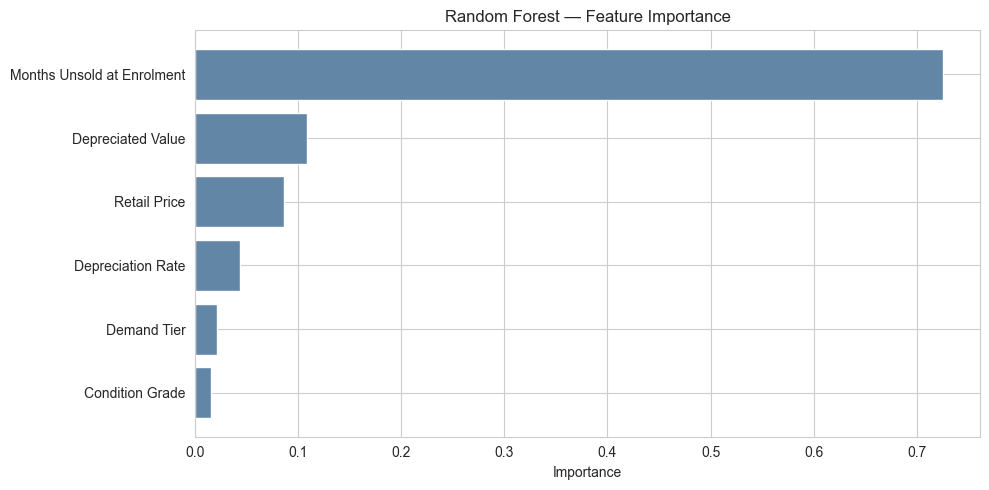

Top feature: months_unsold_at_comparison (0.725)


In [3]:
# Feature importance: which inputs had the most influence on the model's decisions?
# Higher = that feature was more useful for splitting the data correctly
friendly_names = {
    "original_retail_price":       "Retail Price",
    "current_depreciated_value":   "Depreciated Value",
    "avg_depreciation_rate":       "Depreciation Rate",
    "months_unsold_at_comparison": "Months Unsold at Enrolment",
    "demand_tier_enc":             "Demand Tier",
    "condition_enc":               "Condition Grade"
}

fi_sorted = fi.sort_values("importance", ascending=True).copy()
fi_sorted["feature"] = fi_sorted["feature"].map(friendly_names)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(fi_sorted["feature"], fi_sorted["importance"], color=C_BLUE)
ax.set_xlabel("Importance")
ax.set_title("Random Forest — Feature Importance")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Top feature: {fi.iloc[0]['feature']} ({fi.iloc[0]['importance']:.3f})")

## 2 · Model 2 — Revenue Forecasting (Linear Regression)

**Goal:** Project monthly rental revenue forward 6 months to show programme trajectory.

**Why Linear Regression?** The simplest defensible trend model. We're not predicting individual rentals — we're fitting a direction to aggregate monthly revenue and extending it.

> **Honest caveat:** The revenue data was generated with explicit seasonality (Nov/Dec spikes). A linear trend captures the overall direction but not the seasonal shape — R² will reflect this. In a real deployment you would use a seasonal decomposition model (e.g. Prophet). For this project, the linear trend is the appropriate demonstration of the concept.

R² score: 0.771
Monthly trend: +€170 per month on average


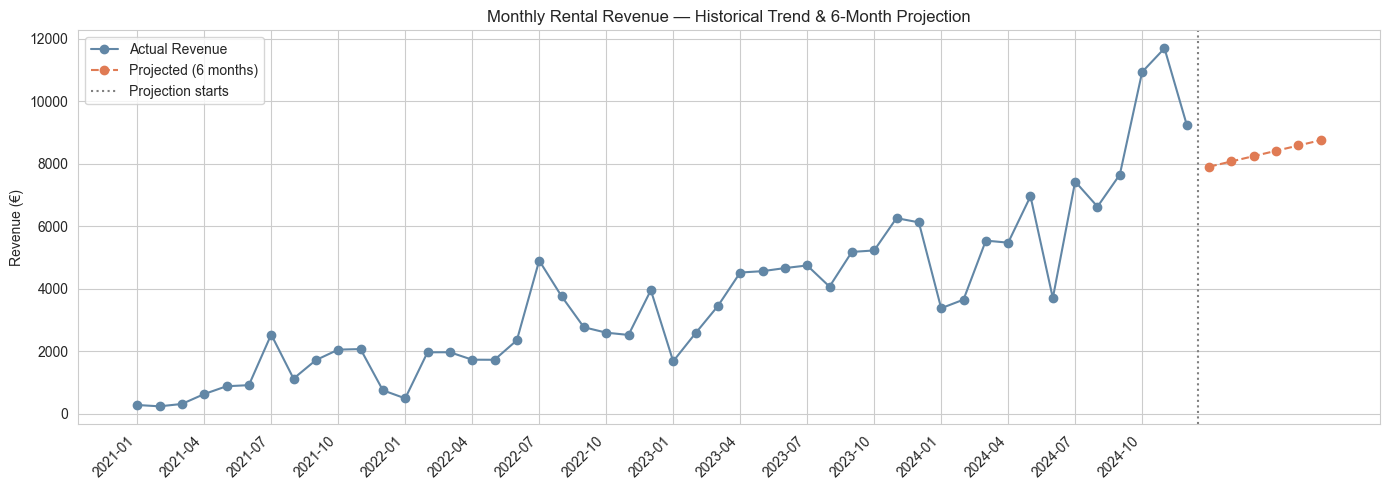

In [4]:
# Model 2: project monthly rental revenue forward 6 months using a linear trend
# This is trend analysis — we fit a straight line to historical revenue and extend it

monthly_rev = rentals.copy()
monthly_rev["month"] = pd.to_datetime(monthly_rev["rental_start_date"]).dt.to_period("M")
monthly_agg = monthly_rev.groupby("month")["total_rental_revenue"].sum().reset_index()
monthly_agg["month_num"] = range(len(monthly_agg))
monthly_agg["month_str"] = monthly_agg["month"].astype(str)

# Fit a linear regression on month number vs revenue
X_lr = monthly_agg["month_num"].values.reshape(-1, 1)
y_lr = monthly_agg["total_rental_revenue"].values

lr_rev = LinearRegression().fit(X_lr, y_lr)
r2 = lr_rev.score(X_lr, y_lr)

# Project 6 months beyond the last data point
future_months = np.arange(len(monthly_agg), len(monthly_agg) + 6).reshape(-1, 1)
projected = lr_rev.predict(future_months)

print(f"R² score: {r2:.3f}")
print(f"Monthly trend: +€{lr_rev.coef_[0]:.0f} per month on average")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(len(monthly_agg)), y_lr, "o-", color=C_BLUE, label="Actual Revenue")
ax.plot(range(len(monthly_agg), len(monthly_agg) + 6), projected, "o--", color=C_ORANGE, label="Projected (6 months)")
ax.axvline(x=len(monthly_agg) - 0.5, color="gray", linestyle=":", linewidth=1.5, label="Projection starts")

# Show month labels every 3 months so x-axis is readable
tick_positions = range(0, len(monthly_agg), 3)
ax.set_xticks(list(tick_positions))
ax.set_xticklabels([monthly_agg["month_str"].iloc[i] for i in tick_positions], rotation=45, ha="right")

ax.set_title("Monthly Rental Revenue — Historical Trend & 6-Month Projection")
ax.set_ylabel("Revenue (€)")
ax.legend()

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/revenue_forecast.png", dpi=150, bbox_inches="tight")
plt.show()


## 3 · Model 3 — Customer Churn Risk (Logistic Regression)

**Goal:** Predict which customers are likely to be return risks — late returns or no-returns.

**Features:** number of past rentals, late return rate, average duration, average spend, customer segment.

**Why Logistic Regression?** Binary classification (risk / not risk), interpretable output, and we care about probability scores per customer — not just a yes/no label.

**Churn label definition:** a customer is flagged as churn risk if their late return rate exceeds 20% OR they have at least one no-return on record. The 20% threshold is a business choice — it flags customers who are consistently late, not occasionally. The no-return condition catches any customer who kept an item entirely, regardless of frequency. This is conservative by design: in a real programme you would tune this threshold against actual write-off costs.

**Note:** `no_return_rate` is used to define the label but excluded from the features — we would not know this in advance for a new customer.

Churn risk customers: 147 (16.6%)

MODEL 3 — CUSTOMER CHURN RISK
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       180
           1       1.00      0.66      0.79        41

    accuracy                           0.94       221
   macro avg       0.96      0.83      0.88       221
weighted avg       0.94      0.94      0.93       221

ROC-AUC: 0.859


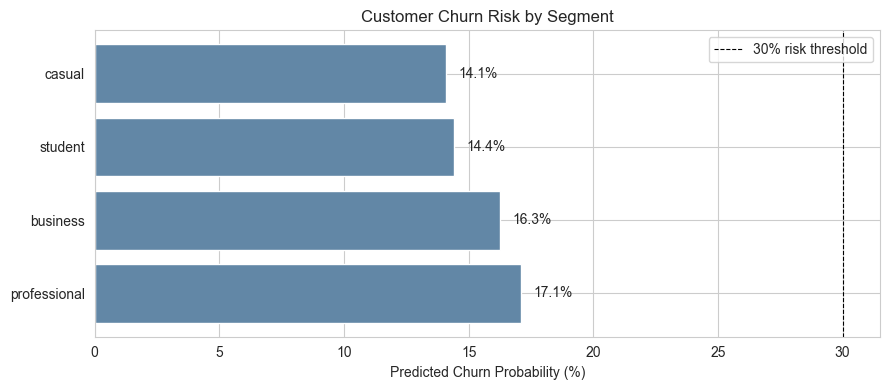

In [5]:
# Model 3: predict which customers are likely to be a return risk
# We define "churn risk" as: late return rate > 20% OR at least one no-return
# This is a business definition we chose — worth being upfront about in a presentation

cust_features = rentals.groupby("customer_id").agg(
    total_rentals=("rental_id", "count"),
    late_return_rate=("is_late", "mean"),
    no_return_rate=("is_no_return", "mean"),
    avg_duration=("rental_duration_days", "mean"),
    avg_spend=("total_rental_revenue", "mean"),
).reset_index()

cust_features = cust_features.merge(
    customers[["customer_id", "customer_segment"]], on="customer_id"
)

# Label: 1 = churn risk, 0 = reliable customer
cust_features["is_churn_risk"] = (
    (cust_features["late_return_rate"] > 0.2) |
    (cust_features["no_return_rate"] > 0)
).astype(int)

print(f"Churn risk customers: {cust_features['is_churn_risk'].sum()} ({cust_features['is_churn_risk'].mean()*100:.1f}%)")

# Encode customer segment
le = LabelEncoder()
cust_features["segment_enc"] = le.fit_transform(cust_features["customer_segment"])

# Note: no_return_rate is used to define the label but excluded as a feature —
# we wouldn't know this in advance for a new customer
features = ["total_rentals", "late_return_rate", "avg_duration", "avg_spend", "segment_enc"]
X = cust_features[features]
y = cust_features["is_churn_risk"]

# Split: 75% train, 25% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)

# Logistic regression: good fit for binary classification with interpretable output
lr_churn = LogisticRegression(max_iter=1000)
lr_churn.fit(X_train, y_train)

# Evaluate
print("\nMODEL 3 — CUSTOMER CHURN RISK")
print(classification_report(y_test, lr_churn.predict(X_test)))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_churn.predict_proba(X_test)[:,1]):.3f}")

# Instead of showing raw coefficients, show predicted churn probability by segment —
# a more concrete business story: which customer type is highest risk?
cust_features["churn_probability"] = lr_churn.predict_proba(X)[:, 1]

segment_risk = cust_features.groupby("customer_segment")["churn_probability"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(segment_risk.index, segment_risk.values * 100,
               color=[C_ORANGE if v > 0.3 else C_BLUE for v in segment_risk.values],
               edgecolor="white")
ax.axvline(x=30, color="black", linewidth=0.8, linestyle="--", label="30% risk threshold")
ax.set_xlabel("Predicted Churn Probability (%)")
ax.set_title("Customer Churn Risk by Segment")
ax.legend()

# Add percentage labels on each bar
for bar, val in zip(bars, segment_risk.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val*100:.1f}%", va="center", fontsize=10)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/churn_risk_by_segment.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 4 · Stress Testing — Sensitivity Analysis & Monte Carlo

> **Note:** Sections 4a and 4b are not machine learning models. They are business analytics stress tests — they ask what happens to the core rental thesis if the cost assumptions in the data generator are wrong. They live here because they are the final validation step before presenting the results.

**Section 4a** tests three fixed scenarios (optimistic / realistic / pessimistic).

**Section 4b** runs 10,000 random simulations varying all uncertain inputs simultaneously using triangular distributions. This is a Monte Carlo simulation — named after the casino, because it uses controlled randomness to explore a range of outcomes.

                   Scenario  Win Rate (%)  Avg Revenue Ratio
 Optimistic\n(10% ops cost)          53.7               1.27
  Realistic\n(18% ops cost)          51.2               1.14
Pessimistic\n(28% ops cost)          46.6               0.75


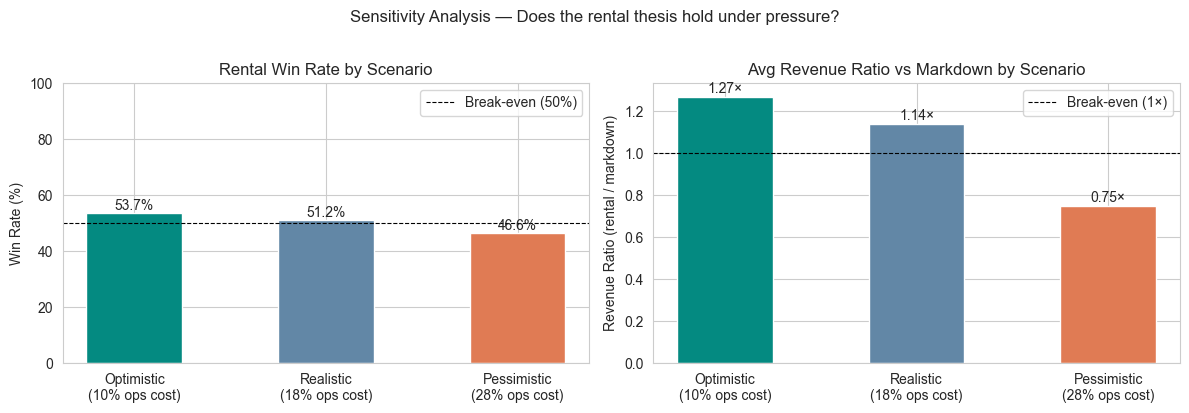

In [6]:
# =============================================================================
# 4a · SENSITIVITY ANALYSIS — Three Scenarios
# We re-calculate the rental win rate and revenue ratio under three cost assumptions.
# This shows whether our thesis holds even if we're wrong about the inputs.
# =============================================================================

scenarios = {
    "Optimistic\n(10% ops cost)": {"ops_cost": 0.10, "no_return": 0.04, "damage": 0.01},
    "Realistic\n(18% ops cost)": {"ops_cost": 0.18, "no_return": 0.063, "damage": 0.025},
    "Pessimistic\n(28% ops cost)": {"ops_cost": 0.28, "no_return": 0.08, "damage": 0.04},
}

results = []
for label, params in scenarios.items():
    # Apply operational cost reduction to rental revenue
    adj_rental = comparison["total_gross_rental_revenue"] * (1 - params["ops_cost"])

    # Apply no-return and damage penalties (those products earn nothing)
    adj_rental = adj_rental.copy()  # defensive: avoid modifying the derived Series in place
    penalty_mask = np.random.rand(len(comparison)) < (params["no_return"] + params["damage"])
    adj_rental[penalty_mask] = 0

    win_rate = (adj_rental > comparison["hypothetical_discount_price"]).mean() * 100
    ratio = (adj_rental / comparison["hypothetical_discount_price"].replace(0, np.nan)).median()

    results.append({"Scenario": label, "Win Rate (%)": round(win_rate, 1), "Avg Revenue Ratio": round(ratio, 2)})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = [C_TEAL, C_BLUE, C_ORANGE]

# Win rate bar chart
axes[0].bar(results_df["Scenario"], results_df["Win Rate (%)"], color=colors, edgecolor="white", width=0.5)
axes[0].axhline(y=50, color="black", linewidth=0.8, linestyle="--", label="Break-even (50%)")
axes[0].set_title("Rental Win Rate by Scenario")
axes[0].set_ylabel("Win Rate (%)")
axes[0].set_ylim(0, 100)
axes[0].legend()
for i, v in enumerate(results_df["Win Rate (%)"]):
    axes[0].text(i, v + 1, f"{v}%", ha="center", fontsize=10)

# Revenue ratio bar chart
axes[1].bar(results_df["Scenario"], results_df["Avg Revenue Ratio"], color=colors, edgecolor="white", width=0.5)
axes[1].axhline(y=1, color="black", linewidth=0.8, linestyle="--", label="Break-even (1×)")
axes[1].set_title("Avg Revenue Ratio vs Markdown by Scenario")
axes[1].set_ylabel("Revenue Ratio (rental / markdown)")
axes[1].legend()
for i, v in enumerate(results_df["Avg Revenue Ratio"]):
    axes[1].text(i, v + 0.02, f"{v}×", ha="center", fontsize=10)

plt.suptitle("Sensitivity Analysis — Does the rental thesis hold under pressure?", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/sensitivity_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

MONTE CARLO RESULTS — 10,000 simulations
Win Rate  | Median: 71.6%  | 5th–95th percentile: 67.8% – 74.7%
Rev Ratio | Median: 1.93×  | 5th–95th percentile: 1.68× – 2.18×

In 100.0% of simulations, rental still beat markdown.


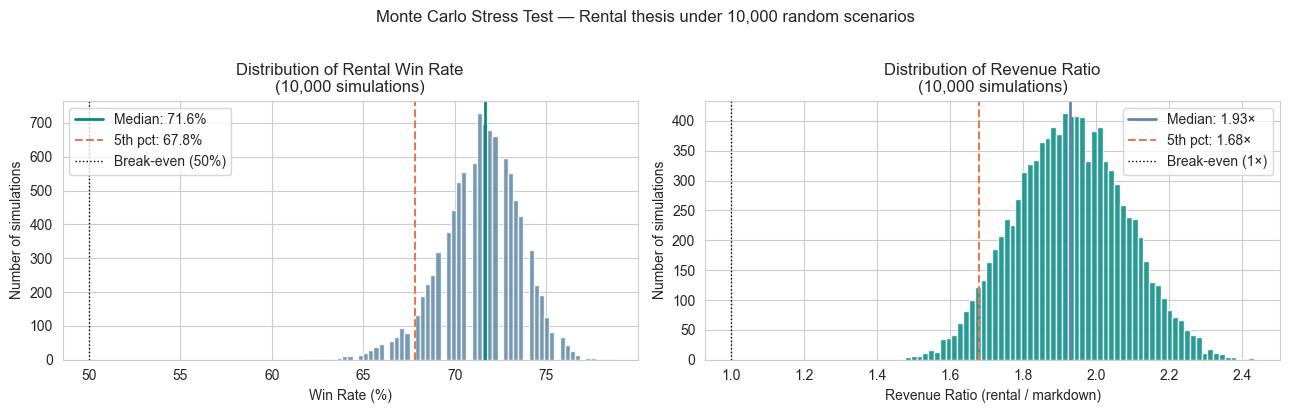

In [9]:
# =============================================================================
# 4b · MONTE CARLO SIMULATION — 10,000 runs
# Instead of three fixed scenarios, we randomly vary all inputs at once.
# Each run picks a random value within realistic ranges for every assumption.
# We record the rental win rate from each run, then look at the full distribution.
# =============================================================================

N_SIMULATIONS = 10_000
np.random.seed(RANDOM_STATE)

win_rates = []
revenue_ratios = []
comparison = comparison[comparison["total_gross_rental_revenue"] > 0].copy()

for _ in range(N_SIMULATIONS):
    # Draw random inputs from realistic ranges (triangular distribution)
    # triangular(low, mode, high) — most likely = middle value, can stretch to edges
    ops_cost     = np.random.triangular(0.10, 0.18, 0.28)   # 10% to 28%, most likely 18%
    no_return    = np.random.triangular(0.04, 0.063, 0.08)  # 4% to 8%, most likely 6.3%
    damage_rate  = np.random.triangular(0.01, 0.025, 0.04)  # 1% to 4%, most likely 2.5%
    revenue_var  = np.random.triangular(0.85, 1.00, 1.10)   # -15% to +10% rental revenue uncertainty

    # Adjust rental revenue
    adj_rental = comparison["total_gross_rental_revenue"] * revenue_var * (1 - ops_cost)

    # Simulate loss events (no-return + damage)
    loss_mask = np.random.rand(len(comparison)) < (no_return + damage_rate)
    adj_rental = adj_rental.copy()
    adj_rental[loss_mask] = 0

    win_rate = (adj_rental > comparison["hypothetical_discount_price"]).mean() * 100
    ratio = (adj_rental / comparison["hypothetical_discount_price"].replace(0, np.nan)).median()

    win_rates.append(win_rate)
    revenue_ratios.append(ratio)

win_rates = np.array(win_rates)
revenue_ratios = np.array(revenue_ratios)

# Summary stats
print("MONTE CARLO RESULTS — 10,000 simulations")
print(f"Win Rate  | Median: {np.median(win_rates):.1f}%  "
      f"| 5th–95th percentile: {np.percentile(win_rates, 5):.1f}% – {np.percentile(win_rates, 95):.1f}%")
print(f"Rev Ratio | Median: {np.median(revenue_ratios):.2f}×  "
      f"| 5th–95th percentile: {np.percentile(revenue_ratios, 5):.2f}× – {np.percentile(revenue_ratios, 95):.2f}×")
print(f"\nIn {(win_rates > 50).mean()*100:.1f}% of simulations, rental still beat markdown.")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Win rate distribution
axes[0].hist(win_rates, bins=60, color=C_BLUE, edgecolor="white", alpha=0.85)
axes[0].axvline(np.median(win_rates), color=C_TEAL, linewidth=2, label=f"Median: {np.median(win_rates):.1f}%")
axes[0].axvline(np.percentile(win_rates, 5), color=C_ORANGE, linewidth=1.5, linestyle="--",
                label=f"5th pct: {np.percentile(win_rates, 5):.1f}%")
axes[0].axvline(50, color="black", linewidth=1, linestyle=":", label="Break-even (50%)")
axes[0].set_title("Distribution of Rental Win Rate\n(10,000 simulations)")
axes[0].set_xlabel("Win Rate (%)")
axes[0].set_ylabel("Number of simulations")
axes[0].legend()

# Revenue ratio distribution
axes[1].hist(revenue_ratios, bins=60, color=C_TEAL, edgecolor="white", alpha=0.85)
axes[1].axvline(np.median(revenue_ratios), color=C_BLUE, linewidth=2,
                label=f"Median: {np.median(revenue_ratios):.2f}×")
axes[1].axvline(np.percentile(revenue_ratios, 5), color=C_ORANGE, linewidth=1.5, linestyle="--",
                label=f"5th pct: {np.percentile(revenue_ratios, 5):.2f}×")
axes[1].axvline(1, color="black", linewidth=1, linestyle=":", label="Break-even (1×)")
axes[1].set_title("Distribution of Revenue Ratio\n(10,000 simulations)")
axes[1].set_xlabel("Revenue Ratio (rental / markdown)")
axes[1].set_ylabel("Number of simulations")
axes[1].legend()

plt.suptitle("Monte Carlo Stress Test — Rental thesis under 10,000 random scenarios", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/monte_carlo.png", dpi=150, bbox_inches="tight")
plt.show()

---
## ✅ ML Deliverables

| # | Model / Analysis | Type | Target | Output |
|---|---|---|---|---|
| 1 | Rental profitability classifier | Random Forest | `is_rental_more_profitable` | `feature_importance.png` |
| 2 | Revenue forecasting | Linear Regression | Monthly rental revenue | `revenue_forecast.png` |
| 3 | Customer churn risk | Logistic Regression | `is_churn_risk` | `churn_risk_by_segment.png` |
| 4a | Sensitivity analysis | Scenario comparison | Win rate & ratio under 3 cost assumptions | `sensitivity_analysis.png` |
| 4b | Monte Carlo simulation | 10,000 random scenarios | Win rate distribution | `monte_carlo.png` |

**→ All analysis complete. Proceed to Power BI dashboards.**